In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
os.chdir("..")

from utils import clean_utils

*League of Legends* presenta 2 opciones para sus partidas del modo clásico. 
- Las partidas *unranked* donde la gente juega por diversión.
- Las partidas *ranked* donde la gente compite para ganar con todo. Dentro de estas, el sistema te asigna un rango.

Para comprobar si esta diferencia de compartamiento es cierta, vamos a explorar nuestras hipótesis: 
- Las partidas casuales presentan más diversidad de campeones que las ranked.
- La duración de las partidas varía según el rango.
- El comportamiento de los jugadores (kills, muertes, duración de partidas) varía en función del nivel medio de la partida.
- En partidas de mayor rango medio, los equipos priorizan más los objetivos que el combate directo.

In [2]:
individual_stats = pd.read_csv("datasets/individual_stats.csv", sep=",")
group_stats = pd.read_csv("datasets/group_stats.csv", sep=",")
champion_tbl = pd.read_csv("datasets/ChampionTbl.csv", sep=",")
rank_tbl = pd.read_csv("datasets/RankTbl.csv", sep=",")

Vamos a comenzar analizando la diversidad de campeones entre rangos.
- El *dataframe* de estadísticas de grupo cada fila contiene los 10 campeones que se han elegido para esa partida. 
- Necesitamos juntarlas en una única variable que nos permita realizar un *groupby()* de manera efectiva.
- Utilizamos el método melt para "apilar" las variables de los campeones ("B1Champ", "B2Champ", ...) en una única variable *"Champion"* manteniendo *"MatchID"* y *"RankFk"*.

In [3]:
# Usar columnas "RankFk" y "ChampionFK"
champ_cols = ["B1Champ", "B2Champ", "B3Champ", "B4Champ", "B5Champ",
              "R1Champ", "R2Champ", "R3Champ", "R4Champ", "R5Champ"]

champs_melted = group_stats.melt(id_vars=["MatchId", "RankFk"], value_vars=champ_cols, value_name="Champion")
champs_melted = champs_melted.drop(columns="variable")
champs_melted.head()


,MatchId,RankFk,Champion
0,EUW1_7524085062,0,50
1,EUW1_7524111529,6,10
2,EUW1_7524129783,5,86
3,EUW1_7524165724,6,54
4,EUW1_7524196416,6,254


Ahora podemos agrupar los campeones por rango y elegir los únicos.

In [4]:
unique_per_rank = champs_melted.groupby("RankFk")["Champion"].nunique()
unique_per_rank

RankFk
0     172
1     172
2     172
3     172
4     172
5     172
6     172
7     172
8     172
9     172
10    172
Name: Champion, dtype: int64

Sorprendentemente, en todos los rangos todos los personajes han aparecido al menos 1 vez (actualmente hay 172 personajes en el juego).

Vamos a pasar a usar el pickrate (el número de veces que se coge cada campeón) para ver si hay algunos campeones que están siendo elegidos con mucha mayor frecuencia que otros.

In [5]:
total_picks_per_rank = champs_melted.groupby("RankFk")["Champion"].count()  # Total number of champion picks in each rank

champ_picks = champs_melted.groupby(["RankFk", "Champion"])["Champion"].count()  # Number of each champion picks in each rank

pick_rate = (champ_picks / total_picks_per_rank)
pick_rate = pick_rate.rename("PickRate").reset_index()  # Create a dataframe
pick_rate.head()

,RankFk,Champion,PickRate
0,0,1,0.001317
1,0,2,0.002490
2,0,3,0.006826
3,0,4,0.004829
4,0,5,0.006546


Ahora ya podemos buscar los campeones más elegidos por rango. Para este análisis miraremos los 3 más elegidos.
- Para estos casos (ver que campeones pueden repetirse más por rango), vamos a utilizar un tipo de *heatmap* que ofrece la librería de seaborn llamado *clustermap*.

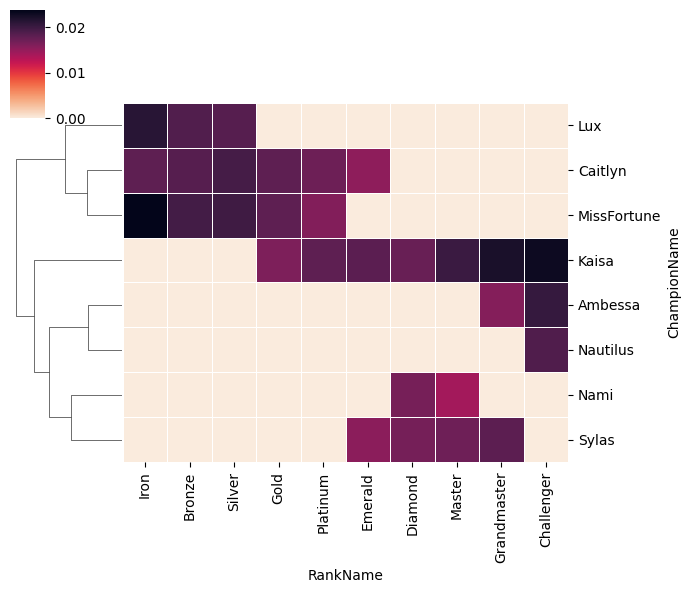

In [6]:
top_n = 3
pick_rate_sorted = pick_rate.sort_values(["RankFk", "PickRate"], ascending=[True, False])
top_n_champs_pickrate = pick_rate_sorted.groupby("RankFk").head(top_n)

top_n_champs_pickrate = pd.merge(top_n_champs_pickrate, rank_tbl, left_on="RankFk", right_on="RankId")
top_n_champs_pickrate = pd.merge(top_n_champs_pickrate, champion_tbl, left_on="Champion", right_on="ChampionId")
top_n_champs_pickrate = top_n_champs_pickrate.drop(columns=["RankFk", "RankId", "ChampionId", "Champion"])
top_n_champs_pickrate

rank_order = ["Unranked", "Iron", "Bronze", "Silver", "Gold", "Platinum", "Emerald", "Diamond", "Master", "Grandmaster", "Challenger"]
top_n_champs_pickrate["RankName"] = pd.Categorical(top_n_champs_pickrate["RankName"], categories=rank_order, ordered=True)
top_n_champs_pickrate = top_n_champs_pickrate.sort_values("RankName")
top_n_champs_pickrate_ranked = top_n_champs_pickrate[top_n_champs_pickrate["RankName"] != "Unranked"]

heatmap_df = top_n_champs_pickrate_ranked.pivot(index="ChampionName", columns="RankName",values="PickRate")
heatmap_df = heatmap_df.fillna(0)

sns.clustermap(heatmap_df, cmap="rocket_r", linewidths=0.5, figsize=(7, 6), metric="euclidean", method="average", col_cluster=False)


Podemos ver que los ranogs bajos tienen claramente unos personajes favoritos, mientras que los rangos altos tienen otro grupo de personajes favoritos. El meta cambia entre los rangos bajos y altos.

Sin embargo, ¿qué hay de la concentración de personajes?. Vamos a evaluar si en rangos altos hay menos diversidad de campeones.
- Para ello, vamos a ordenar el *Pickrate* de todos los campeones e ir sumando poco a poco sus *Pickrates*.
    - Los rangos altos deberían tener una curva más pronunciada al principio y más plana al final.
    - Los rangos bajos deberían tener una curva constante, ya que el pickrate se reparte entre más campeones.

(0.0, 1.0)

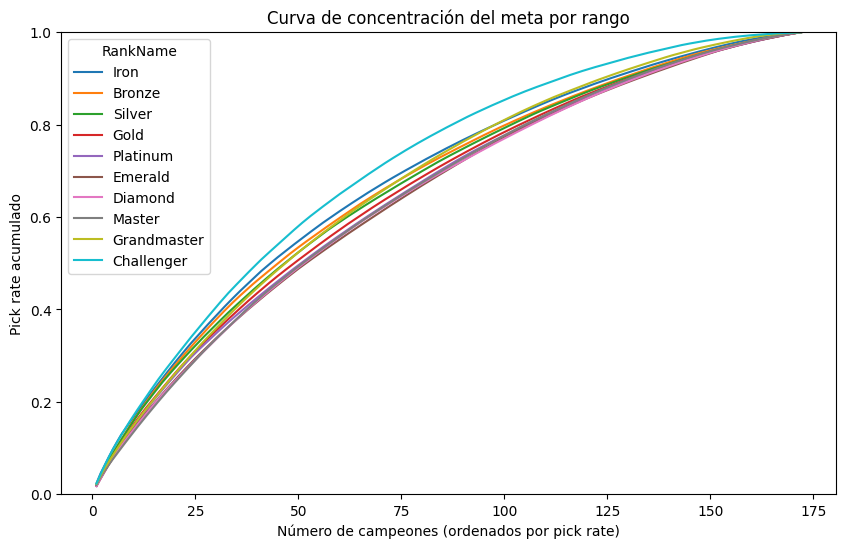

In [7]:
df = pick_rate.copy()
df = df.sort_values(["RankFk", "PickRate"], ascending=[True, False])

df["pos"] = df.groupby("RankFk").cumcount() + 1
df["cum_pick"] = df.groupby("RankFk")["PickRate"].cumsum()
df["total"] = df.groupby("RankFk")["PickRate"].transform("sum")
df["cum_share"] = df["cum_pick"] / df["total"]

df = pd.merge(df, rank_tbl, left_on="RankFk", right_on="RankId")
df = df.drop(columns=["RankFk", "RankId"])
df= df[df["RankName"] != "Unranked"]

plt.figure(figsize=(10,6))

sns.lineplot(data=df, x="pos", y="cum_share", hue="RankName")

plt.title("Curva de concentración del meta por rango")
plt.xlabel("Número de campeones (ordenados por pick rate)")
plt.ylabel("Pick rate acumulado")
plt.ylim(0, 1)


A diferencia de lo que esperábamos, únicamente la curva de *Challenger* es distinguible al resto de curvas.
Para el resto de rangos, el *Pickrate* se reparte de manera parecida.
- Esto sugiere que la mayor diferencia entre rangos altos y bajos es en los campeones elegidos.

Ahora vamos a evaluar si hay diferencias respecto a la duración de la partida.

Antes de comenzar, es necesario eliminar ciertas partidas con una duración extremadamente corta (menor a 5 minutos).
- En el *LoL* hay partidas que se terminan en los primeros 5 minutos (300 segundos) porque alguien se ha desconectado y no tendría sentido jugar una partida 4 vs 5. Esto son outliers que debemos eliminar antes de comenzar con el análisis.
- También quitaremos las partidas de más de 1 hora (3600 segundos) ya que son muy poco comunes.

In [9]:
duration_stats = group_stats[["MatchId", "RankFk", "GameDuration"]]
duration_stats = duration_stats[(duration_stats["GameDuration"] > 300) & (duration_stats["GameDuration"] < 3600)]
duration_stats = duration_stats[duration_stats["RankFk"] != 0]
duration_stats = duration_stats.merge(rank_tbl, left_on="RankFk", right_on="RankId")
duration_stats["GameDurationMin"] = duration_stats["GameDuration"] / 60


Al igual que antes, ordenamos los rangos de menor a mayor para una visualización más clara. 
- Vamos a utilizar *boxplots* para ver la duración media de las partidas.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Iron'),
  Text(1, 0, 'Bronze'),
  Text(2, 0, 'Silver'),
  Text(3, 0, 'Gold'),
  Text(4, 0, 'Platinum'),
  Text(5, 0, 'Emerald'),
  Text(6, 0, 'Diamond'),
  Text(7, 0, 'Master'),
  Text(8, 0, 'Grandmaster'),
  Text(9, 0, 'Challenger')])

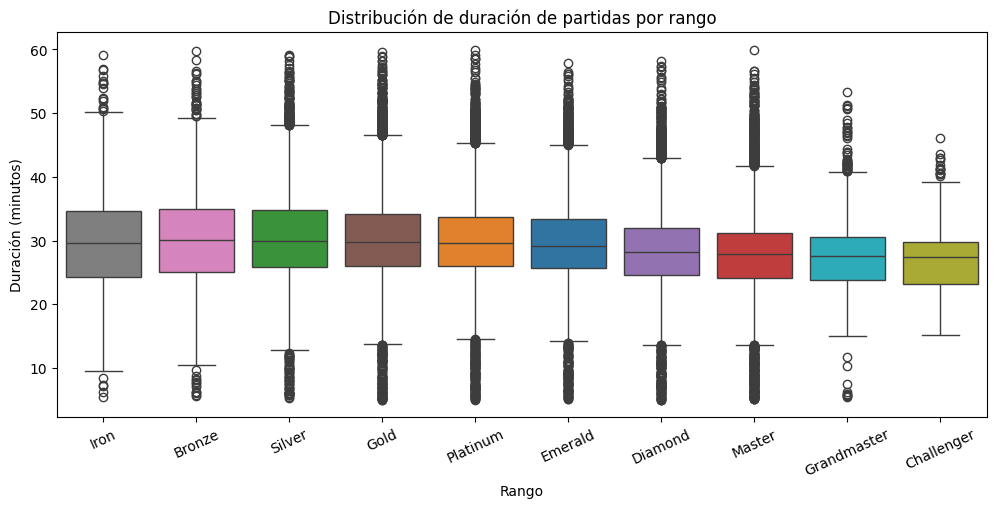

In [10]:
rank_order = ["Iron", "Bronze", "Silver", "Gold", "Platinum", "Emerald", "Diamond", "Master", "Grandmaster", "Challenger"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=duration_stats, x="RankName", y="GameDurationMin", order=rank_order, hue="RankName")
ax.set_xlabel("Rango")
ax.set_ylabel("Duración (minutos)")
ax.set_title("Distribución de duración de partidas por rango")
plt.xticks(rotation=25)

Aunque leve, podemos ver que la duración de las partidas va disminiyundo conforme aumenta el rango.
- Adicionalmente, también parece que el rango entre el Q1 y el Q3 (Inter Quartile Range IQR) disminiuye conforme aumenta el rango.

Esto confirma la hipótesis de que las partidas de rango más alto duran menos ya que:
- Los jugadores de rango alto saben cerrar las partidas más rápido.
- Conforme aumenta el rango, las partidas varían menos en duración ya que los equipos saben no perder muy rápido (menos partidas cortas) y cerrar partidas (menos partidas largas).

Finalmente, vamos con la hipótesis de que en las partidas de rango más alto, se priorizan más los objetivos que el combate.
- Necesitamos sumar las columnas que cuentan los objetivos y las columnas que cuentan las kills.

In [14]:
group_stats2 = group_stats.copy()
group_stats2["TotalKills"] = group_stats2["BlueKills"] + group_stats2["RedKills"]
group_stats2["TotalTowers"] = group_stats2["BlueTowerKills"] + group_stats2["RedTowerKills"]
group_stats2["TotalDragons"] = group_stats2["BlueDragonKills"] + group_stats2["RedDragonKills"]
group_stats2["TotalBarons"] = group_stats2["BlueBaronKills"] + group_stats2["RedBaronKills"]
group_stats2["GameDurationMin"] = group_stats2["GameDuration"] / 60

Para poder realizar la comparación entre partidas de diferente duración (partidas más largas tendrán más kills y objetivos), vamos a crear unos simples ratios de "kills/minuto" y "objetivos/minuto".
- Adicionalmente, creamos un ratio unificado con ambos.

In [15]:
group_stats2["KillsPerMin"] = group_stats2["TotalKills"] / group_stats2["GameDurationMin"]
group_stats2["ObjPerMin"] = (group_stats2["TotalTowers"] + group_stats2["TotalDragons"] + group_stats2["TotalBarons"]) / group_stats2["GameDurationMin"]
group_stats2["ObjCombatRatio"] = group_stats2["ObjPerMin"] / group_stats2["KillsPerMin"]

Ahora vamos con la visualización. Vamos a utilizar un *lineplot* para ver si las líneas de cada rango divergen.

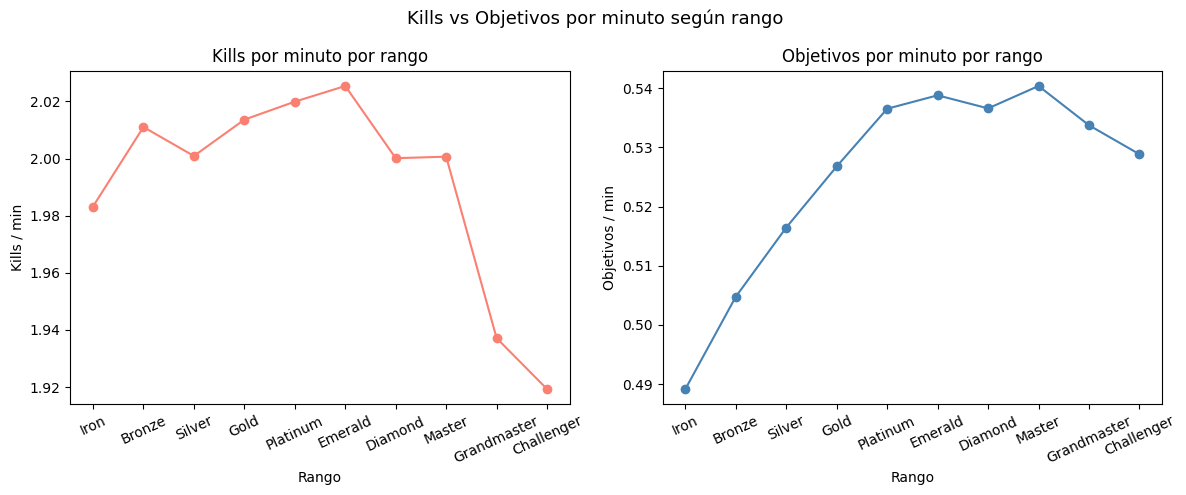

In [19]:
rank_order = ["Iron", "Bronze", "Silver", "Gold", "Platinum", "Emerald", "Diamond", "Master", "Grandmaster", "Challenger"]
group_stats2 = group_stats2[group_stats2["RankFk"] != 0]
group_ranked = pd.merge(group_stats2, rank_tbl, left_on="RankFk", right_on="RankId")

rank_means = group_ranked.groupby("RankName")[["KillsPerMin", "ObjPerMin"]].mean().reindex(rank_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(rank_order, rank_means["KillsPerMin"], marker="o", color="salmon")
axes[0].set_title("Kills por minuto por rango")
axes[0].set_xlabel("Rango")
axes[0].set_ylabel("Kills / min")
axes[0].tick_params(axis="x", rotation=25)

axes[1].plot(rank_order, rank_means["ObjPerMin"], marker="o", color="steelblue")
axes[1].set_title("Objetivos por minuto por rango")
axes[1].set_xlabel("Rango")
axes[1].set_ylabel("Objetivos / min")
axes[1].tick_params(axis="x", rotation=25)

fig.suptitle("Kills vs Objetivos por minuto según rango", fontsize=13)
plt.tight_layout()

Podemos ver claramente que los objetivos por minuto aumentan en función que sube el rango medio de la partida. Lo que confirma la hipótesis.
- Por otro lado, el combate, aunque no tan claro, tienda a elevarse ligeramente para rangos medios y bajar mucho en rangos altos.

Esto es esperable, ya que los jugadores buenos tienden a pelearse solo cuando quieren conseguir un objetivos, mientras que en rangos más bajos los jugadores se pelean porque "es divertido".